UNET NOTEBOOK

In [1]:
import os
import copy
import torch
import sys
import torch.optim as optim
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader

In [2]:
p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "scripts").exists())
sys.path.insert(0, str(repo_root / "scripts"))

In [3]:

from voc_datasets import build_voc_datasets, NUM_CLASSES, IGNORE_INDEX
from unet import UNet
from losses import get_ce_loss
from train_utils import train_one_epoch, validate_one_epoch, save_checkpoint, count_parameters

In [4]:
#CONFIG
ROOT = r"c:/Users/Kwame Boateng/Documents/GitHub/semantic-segmentation/Data"
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "unet_best.pt")
LAST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "unet_last.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
train_dataset, val_dataset = build_voc_datasets(
    root=ROOT,
    img_size=IMG_SIZE
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

c:\Users\Kwame Boateng\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Train samples: 209
Val samples: 213


In [6]:
#Load Data
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

images, masks = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch mask shape:", masks.shape)

Batch image shape: torch.Size([8, 3, 256, 256])
Batch mask shape: torch.Size([8, 256, 256])


In [7]:
#Create model
model = UNet(in_channels=3, num_classes=NUM_CLASSES).to(device)
criterion = get_ce_loss(ignore_index=IGNORE_INDEX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print("Trainable parameters:", count_parameters(model))

UNet(
  (inc): DoubleConv(
    (layers): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
    )
  )
  (down1): Down(
    (down): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (layers): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [8]:
history = {
    "train_loss": [],
    "train_pixel_acc": [],
    "train_mean_iou": [],
    "train_mean_dice": [],
    "val_loss": [],
    "val_pixel_acc": [],
    "val_mean_iou": [],
    "val_mean_dice": [],
}

best_val_miou = -1.0
best_epoch = -1
best_model_state = None

In [9]:
#Training Loop
for epoch in range(NUM_EPOCHS):
    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    val_metrics = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    history["train_loss"].append(train_metrics["loss"])
    history["train_pixel_acc"].append(train_metrics["pixel_acc"])
    history["train_mean_iou"].append(train_metrics["mean_iou"])
    history["train_mean_dice"].append(train_metrics["mean_dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_pixel_acc"].append(val_metrics["pixel_acc"])
    history["val_mean_iou"].append(val_metrics["mean_iou"])
    history["val_mean_dice"].append(val_metrics["mean_dice"])

    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")
    print(
        f"  Train | Loss: {train_metrics['loss']:.4f} | "
        f"Pixel Acc: {train_metrics['pixel_acc']:.4f} | "
        f"mIoU: {train_metrics['mean_iou']:.4f} | "
        f"mDice: {train_metrics['mean_dice']:.4f}"
    )
    print(
        f"  Val   | Loss: {val_metrics['loss']:.4f} | "
        f"Pixel Acc: {val_metrics['pixel_acc']:.4f} | "
        f"mIoU: {val_metrics['mean_iou']:.4f} | "
        f"mDice: {val_metrics['mean_dice']:.4f}"
    )

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        metrics=val_metrics,
        save_path=LAST_MODEL_PATH,
    )

    if val_metrics["mean_iou"] > best_val_miou:
        best_val_miou = val_metrics["mean_iou"]
        best_epoch = epoch + 1
        best_model_state = copy.deepcopy(model.state_dict())

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=val_metrics,
            save_path=BEST_MODEL_PATH,
        )

        print(f"  Saved new best model at epoch {best_epoch} with val mIoU = {best_val_miou:.4f}")

    print("-" * 60)

Epoch [1/50]
  Train | Loss: 2.7360 | Pixel Acc: 0.4040 | mIoU: 0.0310 | mDice: 0.0454
  Val   | Loss: 2.0820 | Pixel Acc: 0.7378 | mIoU: 0.0636 | mDice: 0.0732
  Saved new best model at epoch 1 with val mIoU = 0.0636
------------------------------------------------------------
Epoch [2/50]
  Train | Loss: 2.4422 | Pixel Acc: 0.5736 | mIoU: 0.0419 | mDice: 0.0564
  Val   | Loss: 2.4951 | Pixel Acc: 0.5553 | mIoU: 0.0398 | mDice: 0.0523
------------------------------------------------------------
Epoch [3/50]
  Train | Loss: 2.3000 | Pixel Acc: 0.5959 | mIoU: 0.0444 | mDice: 0.0581
  Val   | Loss: 2.5200 | Pixel Acc: 0.4874 | mIoU: 0.0362 | mDice: 0.0494
------------------------------------------------------------
Epoch [4/50]
  Train | Loss: 2.1766 | Pixel Acc: 0.5797 | mIoU: 0.0505 | mDice: 0.0668
  Val   | Loss: 2.3293 | Pixel Acc: 0.5327 | mIoU: 0.0460 | mDice: 0.0607
------------------------------------------------------------
Epoch [5/50]
  Train | Loss: 2.0638 | Pixel Acc: 0.5989

In [10]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Best epoch:", best_epoch)
print("Best val mIoU:", best_val_miou)

Best epoch: 35
Best val mIoU: 0.0980916657778019


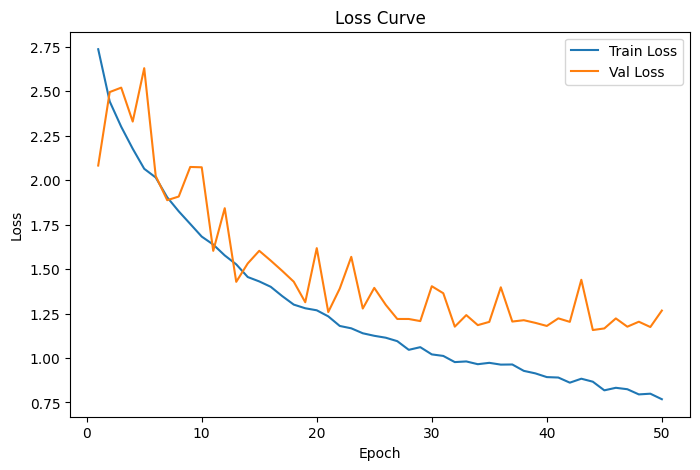

In [11]:
epochs = range(1, NUM_EPOCHS + 1)

#Training Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

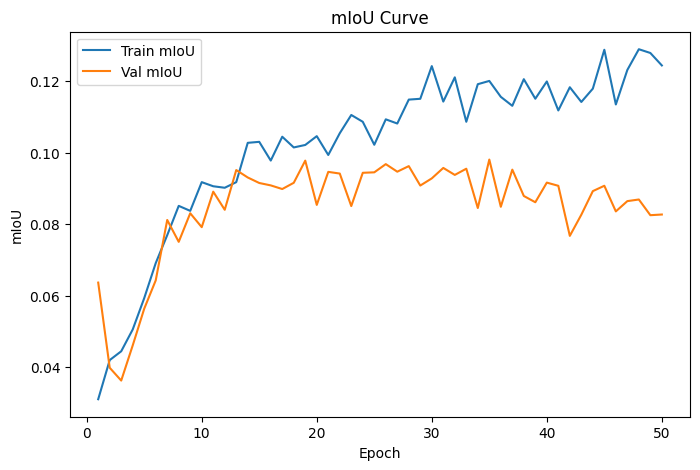

In [12]:
#mIOU
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_mean_iou"], label="Train mIoU")
plt.plot(epochs, history["val_mean_iou"], label="Val mIoU")
plt.xlabel("Epoch")
plt.ylabel("mIoU")
plt.title("mIoU Curve")
plt.legend()
plt.show()

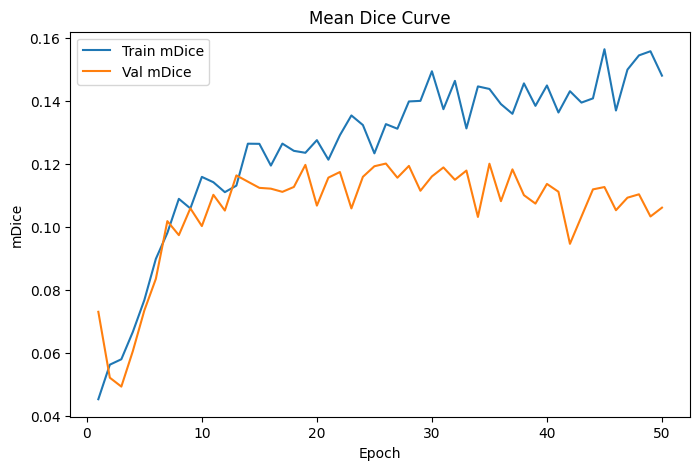

In [13]:
#Dice
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_mean_dice"], label="Train mDice")
plt.plot(epochs, history["val_mean_dice"], label="Val mDice")
plt.xlabel("Epoch")
plt.ylabel("mDice")
plt.title("Mean Dice Curve")
plt.legend()
plt.show()

In [14]:
#Validation Pass
final_val_metrics = validate_one_epoch(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Final validation metrics (best loaded model):")
for k, v in final_val_metrics.items():
    print(f"{k}: {v:.4f}")

Final validation metrics (best loaded model):
loss: 1.2031
pixel_acc: 0.7311
mean_iou: 0.0981
mean_dice: 0.1201
